In [18]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets as datasetsvision
from torchvision import transforms
from PIL import Image, ImageFilter
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.decomposition import PCA
import pandas as pd
import random

In [53]:
def make_mlp(input_dim: int, hidden_dim: int, output_dim: int, n_layers: int = 2):
    layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
    layers.append(nn.Linear(hidden_dim, output_dim))
    return nn.Sequential(*layers)


In [54]:
class CouplingBlock(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size = None, n_layers = 2):
        super(CouplingBlock, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size

        half = input_size // 2

        if condition_size is None:
            self.nested_scale = make_mlp(half, hidden_size, half, n_layers)
            self.nested_translate = make_mlp(half, hidden_size, half, n_layers)
        else:
            in_dim = condition_size + half
            self.nested_scale = make_mlp(in_dim, hidden_size, half, n_layers)
            self.nested_translate = make_mlp(in_dim, hidden_size, half, n_layers)

    def forward(self, x, condition=None):
        x1, x2 = x[:, :self.input_size // 2], x[:, self.input_size // 2:]
        if condition is None:
            z1 = x1
            scale = torch.exp(torch.tanh(self.nested_scale(x1)))
            z2 = x2 * scale + self.nested_translate(x1)
        else:
            x1_conditioned = torch.cat([x1, condition], dim=1)
            scale = torch.exp(torch.tanh(self.nested_scale(x1_conditioned)))
            z1 = x1
            z2 = x2 * scale + self.nested_translate(x1_conditioned)

        return torch.cat([z1,z2], dim=1), scale
    
    def reverse(self, Z, condition=None):
        z1, z2 = Z[:, :self.input_size // 2], Z[:, self.input_size // 2:]
        if condition is None:
            scale =  torch.exp(torch.tanh(self.nested_scale(z1)))
            x1 = z1
            x2 = (z2 - self.nested_translate(z1)) / scale
        else:
            z1_conditioned = torch.cat([z1, condition],dim=1)
            scale = torch.exp(torch.tanh(self.nested_scale(z1_conditioned)))
            x1 = z1
            x2 = (z2 - self.nested_translate(z1_conditioned)) / scale
        return torch.cat([x1,x2], dim=1)

In [55]:
class RealNVP(nn.Module):
    def __init__(self, input_size, hidden_size, blocks, condition_size = None):
        super(RealNVP, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size
        if condition_size is None:
            self.coupling_blocks = nn.ModuleList([
                CouplingBlock(input_size, hidden_size) for _ in range(blocks)
            ])
        else:
            self.coupling_blocks = nn.ModuleList([
                CouplingBlock(input_size, hidden_size, condition_size) for _ in range(blocks)
            ])
        self.rotations = [torch.linalg.qr(torch.randn(input_size, input_size))[0] for _ in range(blocks - 1)]
        self.rotations = nn.ParameterList([nn.Parameter(rot, requires_grad=False) for rot in self.rotations])
        
    def forward(self, x, condition=None):
        log_det_jacob = 0
        for i, block in enumerate(self.coupling_blocks):
            if condition is None:
                x, scale = block(x)
            else:
                x, scale = block(x, condition)
            log_det_jacob += torch.sum(torch.log(scale), dim=1)
            if i < len(self.rotations):
                x = x @ self.rotations[i]
        return x, log_det_jacob
    
    def reverse(self, z, condition=None):
        for i in reversed(range(len(self.coupling_blocks))):
            if i < len(self.rotations):
                z = z @ self.rotations[i].T
            if condition is None:
                z = self.coupling_blocks[i].reverse(z)
            else:
                z = self.coupling_blocks[i].reverse(z, condition)
        return z
    
    def sample(self, n_samples, conditions=None, n_labels=2):
        if conditions is None:
            gauss = torch.randn(n_samples, self.input_size)
            samples = self.reverse(gauss)
        else:
            conditions = torch.nn.functional.one_hot(torch.tensor(conditions, dtype=torch.int64), num_classes=n_labels).float()
            conditions_repeated = conditions.repeat(n_samples, 1)
            gauss = torch.randn(n_samples * len(conditions), self.input_size)
            samples = self.reverse(gauss, conditions_repeated)

        return samples


In [56]:
def get_moons_unconditional(n_samples=1000, noise=0.1):
    X, _ = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X

def get_moons_conditional(n_samples=1000, noise=0.1):
    X, y = datasets.make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.nn.functional.one_hot(
        torch.tensor(y), num_classes=2
    ).float()
    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    return dataloader, X, y

In [57]:
def train_inn(model, dataloader, n_samples=1000, epochs=100, lr = 0.001):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    loss_values = []

    for _ in range(epochs):
        total_training_loss = 0
        for batch in dataloader:
            x=batch[0]
            if model.condition_size is not None:
                y = batch[1]
                z, log_det_jacob = model(x, y)
            else:
                z, log_det_jacob = model(x)
            loss = torch.mean(1/2 * x.shape[1] * torch.log(torch.tensor(2*torch.pi)) + 1/2 * torch.sum(z ** 2, dim=1) - log_det_jacob)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_training_loss += loss.item()
        loss_values.append(total_training_loss)

    return model, loss_values    

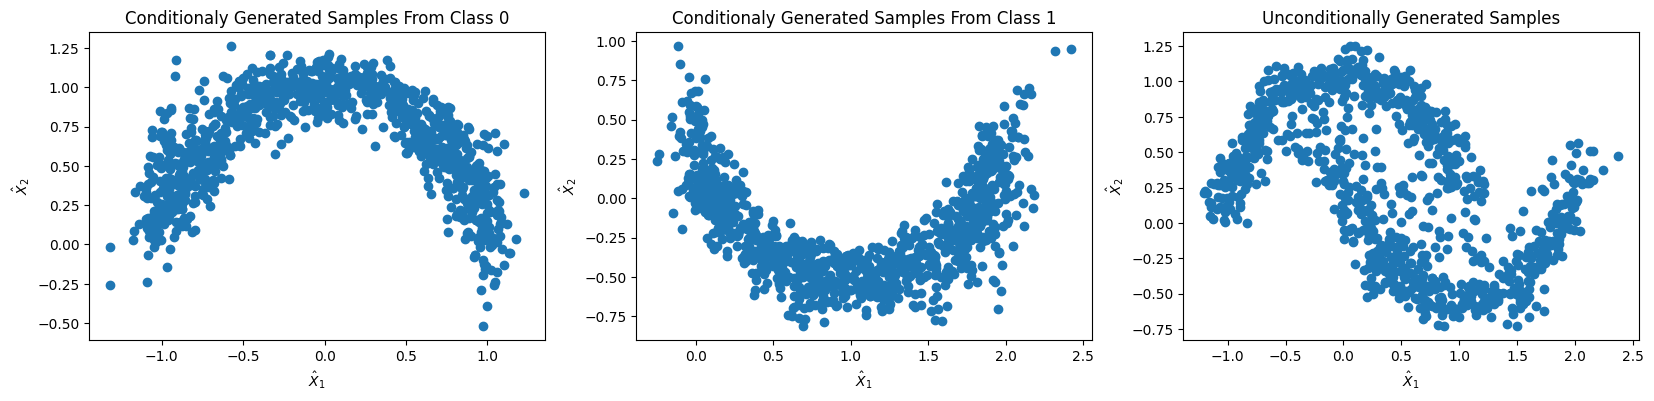

In [60]:

uncond_loader, X_uncond = get_moons_unconditional()
cond_loader, X_cond, y_cond = get_moons_conditional()

input_size = X_uncond.shape[1]
hidden_size = 32
n_blocks = 5
condition_size = 2 

rnvp = RealNVP(input_size, hidden_size, n_blocks)
cond_rnvp = RealNVP(input_size, hidden_size, n_blocks, condition_size)

rnvp, losses = train_inn(rnvp, uncond_loader)
cond_rnvp, cond_losses = train_inn(cond_rnvp, cond_loader)

gen_X = rnvp.sample(1000)


gen_moon_0 = cond_rnvp.sample(1000, [0])
gen_moon_1 = cond_rnvp.sample(1000, [1])

fig, axs = plt.subplots(1,3, figsize=(20,4))

axs[0].set_title("Conditionaly Generated Samples From Class 0")
axs[0].scatter(gen_moon_0[:,0].detach().numpy(), gen_moon_0[:,1].detach().numpy())
axs[0].set_xlabel(r"$\hat{X}_1$")
axs[0].set_ylabel(r"$\hat{X}_2$")

axs[1].set_title("Conditionaly Generated Samples From Class 1")
axs[1].scatter(gen_moon_1[:,0].detach().numpy(), gen_moon_1[:,1].detach().numpy())
axs[1].set_xlabel(r"$ \hat{X}_1$")
axs[1].set_ylabel(r"$ \hat{X}_2$")

axs[2].set_title("Unconditionally Generated Samples")
axs[2].scatter(gen_X.detach().numpy()[:,0], gen_X.detach().numpy()[:,1], label="Generated Data")
axs[2].set_xlabel(r"$\hat{X}_1$")
axs[2].set_ylabel(r"$\hat{X}_2$")

plt.show()

In [61]:
def plot_lc(losses):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.show()

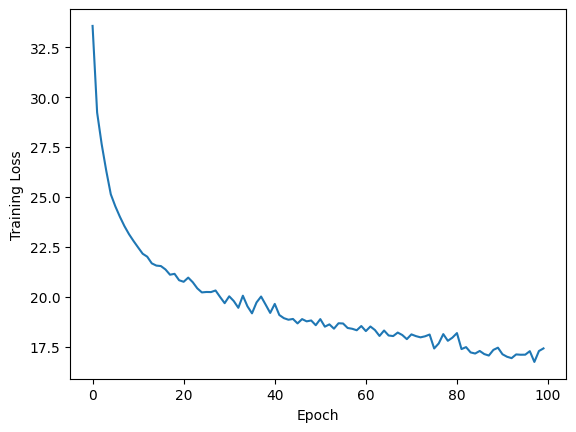

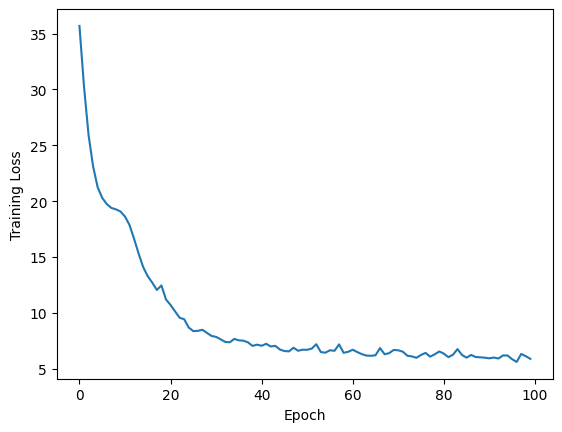

In [62]:
plot_lc(losses=losses)
plot_lc(cond_losses)